# SDN Traffic Prediction using ARIMA
### Networking II Project

Our project uses Mininet with Open vSwitch — the standard platform for SDN research and emulation. The network topology, traffic flows, and packet capture are all controlled programmatically from a central script, which is the fundamental SDN principle of separating the control plane from the data plane. The switches run in standalone mode with STP, since the focus should be on traffic characteristics and prediction rather than SDN protocol implementation.

---

This notebook demonstrates the full pipeline for predicting network traffic
in a Software-Defined Network (SDN) environment:

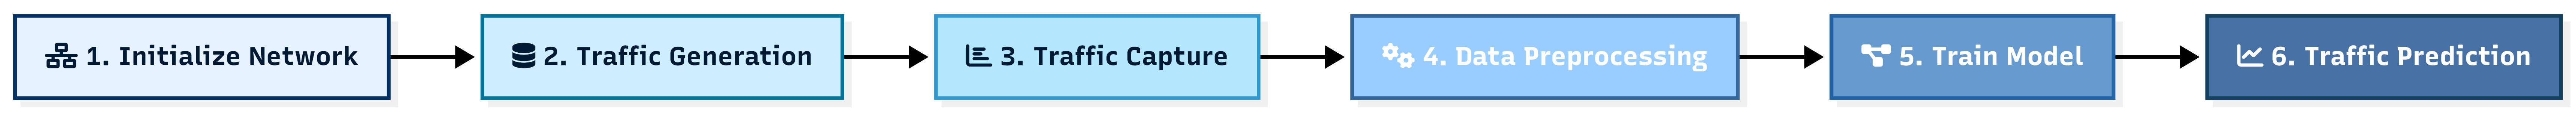

This diagram shows the complete architecture of our project running inside ComNetsEmu — a network emulation environment built on top of Vagrant and Mininet.

Everything runs inside a ComNetsEmu virtual machine on our Windows laptop. ComNetsEmu provides the Ubuntu environment with Mininet, Open vSwitch, and all the Python dependencies pre-installed

We have three Python scripts. ``main.py`` is the orchestrator — it builds the topology, starts the traffic generators, and manages the packet capture. ```traffic_gen.py``` generates the structured intermittent traffic using iperf — it sends for 5 seconds, pauses for 1 second, then repeats with a new random bandwidth. ```traffic_pred.py``` reads the captured CSV files, preprocesses them into a Mbps time series, fits the ARIMA model, and produces the prediction plots.

<img src="Architecture.jpg" width="700" height="400"/>

 standalone mode — OVS configures itself using standard MAC learning without a live OpenFlow channel. The Southbound Interface here is implicit — Mininet uses ovs-vsctl commands at startup to configure the OVS bridges and ports.

 Inside Mininet we have two OVS switches — s1 and s2 — connected by a backbone link. Each switch has two hosts attached. The backbone link carries all inter-switch traffic and is the most interesting interface for traffic prediction.

 Scapy sniffers

- On each switch Scapy's AsyncSniffer is attached to every interface. It records every packet — timestamp and length in bytes — into CSV files in the captures/ folder. This raw packet log is what feeds the ARIMA prediction pipeline.

CSV arrow (red dashed)

- The captured CSV files flow from Scapy to traffic_pred.py. The prediction script resamples these into 1-second bins, converts bytes to Mbps, and trains ARIMA on 75% of the resulting time series, forecasting the remaining 25% blindly.

iperf flows arrow (green dashed)

- traffic_gen.py sends structured ON/OFF iperf traffic directly into the Mininet network — 5 seconds on at a random bandwidth between 0.2 and 1.0 Mbps, then 1 second of silence.

ComNetsEmu gives us the environment, Mininet gives us the virtual network, OVS handles packet forwarding, our Python scripts control everything and capture data, and ARIMA learns from that data to predict future traffic


## Install and Import Dependencies

In [27]:
# Install required libraries if not already present
%pip install statsmodels pandas numpy matplotlib --quiet

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('All libraries loaded successfully.')

Note: you may need to restart the kernel to use updated packages.
All libraries loaded successfully.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\yohan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## Step 1:  Configuration

Each CSV file was captured by Scapy from one switch interface during the Mininet experiment.

The backbone link between s1 and s2 (interface `eth1` on either switch)
carries the most mixed traffic and gives the most interesting prediction results.

In [28]:
CSV_FILE       = 'captures2/s2/eth2.csv'   # interface to analyse
SAMPLE_PERIOD  = '1s'                      # resample to 1-second bins
TRAINING_SPLIT = 0.75                      # 75% train, 25% blind test
ARIMA_ORDER    = (30, 0, 0)               # (p, d, q)
# 

print(f'CSV file       : {CSV_FILE}')
print(f'Sample period  : {SAMPLE_PERIOD}')
print(f'Training split : {TRAINING_SPLIT*100:.0f}% train / '
      f'{(1-TRAINING_SPLIT)*100:.0f}% blind test')
print(f'ARIMA order    : {ARIMA_ORDER}')

CSV file       : captures2/s2/eth2.csv
Sample period  : 1s
Training split : 75% train / 25% blind test
ARIMA order    : (30, 0, 0)


---
## Step 2:  Data Loading

The CSV file was written by Scapy's `AsyncSniffer` during the Mininet experiment.
Each row represents one captured packet with two columns:

| Column | Type | Description |
|--------|------|-------------|
| `ds` | float | Unix timestamp (seconds since epoch) |
| `y` | int | Packet length in bytes |

At this stage the data is raw — thousands of individual packet records.

In [29]:
# Load the raw CSV file
raw_df = pd.read_csv(CSV_FILE)

print(f'Total packets captured : {len(raw_df):,}')
print(f'Experiment duration    : {raw_df["ds"].max() - raw_df["ds"].min():.1f} seconds')
print(f'Average packet size    : {raw_df["y"].mean():.1f} bytes')
print(f'\nFirst 5 rows:')
raw_df.head()

Total packets captured : 9,124
Experiment duration    : 120.2 seconds
Average packet size    : 1429.1 bytes

First 5 rows:


,ds,y
0,1.781091e+09,2962
1,1.781091e+09,66
2,1.781091e+09,2962
3,1.781091e+09,66
4,1.781091e+09,66


---
## Data Processing

Raw packet logs cannot be fed directly to ARIMA — the model needs a **regular time series**
with one value per fixed time interval.

The processing pipeline:

```
Raw packets (thousands of rows)
    │
     Parse timestamps: unix float → pandas DatetimeIndex
    │
    Resample: sum all bytes in each 1-second bin
    │            fill empty bins with 0 (silence = 0 bytes)
    │
    Convert: bytes/bin → Mbps
    │           Mbps = (bytes × 8) / (bin_seconds × 2²⁰)
    │
    Regular Mbps time series (one row per second)
```

**Why 1-second bins?**
Fine bins (0.2S) produce very noisy spike-like series with low autocorrelation.
1-second bins smooth the signal into waves that ARIMA can learn from.

In [16]:
# Step 1: parse unix timestamps to pandas DatetimeIndex
df = pd.read_csv(CSV_FILE)
df['ds'] = pd.to_datetime(df['ds'], unit='s')
df.set_index('ds', inplace=True)

# Step 2: resample into fixed bins — sum bytes in each bin, fill silence with 0
df = df.resample(SAMPLE_PERIOD).sum(numeric_only=True).fillna(0)

# Step 3: convert bytes/bin → Mbps
bin_seconds = pd.Timedelta(SAMPLE_PERIOD).total_seconds()
df['y'] = (df['y'] * 8) / (bin_seconds * 2**20)

# Summary statistics
zeros   = (df['y'] == 0).sum()
nonzero = (df['y'] > 0).sum()

print(f'Time series length : {len(df)} rows (one per second)')
print(f'Mean traffic       : {df["y"].mean():.4f} Mbps')
print(f'Max traffic        : {df["y"].max():.4f} Mbps')
print(f'Min traffic        : {df["y"].min():.4f} Mbps')
print(f'Zero bins          : {zeros}/{len(df)} ({100*zeros//len(df)}% silence)')
print(f'\nFirst 10 rows of the processed series:')
df.head(10)

Time series length : 121 rows (one per second)
Mean traffic       : 0.8222 Mbps
Max traffic        : 1.9563 Mbps
Min traffic        : 0.0231 Mbps
Zero bins          : 0/121 (0% silence)

First 10 rows of the processed series:


,y
ds,
2026-06-10 11:27:58,0.786972
2026-06-10 11:27:59,0.023605
2026-06-10 11:28:00,0.880783
2026-06-10 11:28:01,1.749298
2026-06-10 11:28:02,0.694214
2026-06-10 11:28:03,1.553177
2026-06-10 11:28:04,0.618073
2026-06-10 11:28:05,0.753738
2026-06-10 11:28:06,0.428787


---
## Data Visualisation

The plot below shows the full Mbps time series.
- **ON phases**: regular bursts of traffic lasting ~5 seconds
- **OFF phases**: 1-second gaps of silence between bursts
- **Varying amplitude**: each burst has a different height (random bandwidth per cycle)

This structured ON/OFF pattern is what gives ARIMA enough autocorrelation to forecast.

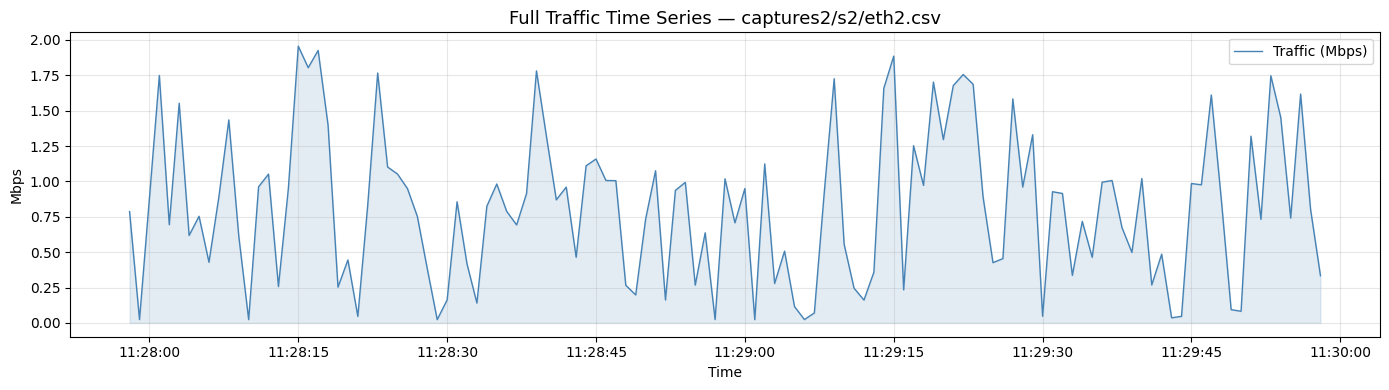

Observation: You can see the regular ON/OFF pattern — 5 seconds of traffic followed by ~1 second of silence, repeating throughout the experiment.


In [15]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['y'], color='steelblue', linewidth=1.0, label='Traffic (Mbps)')
ax.fill_between(df.index, 0, df['y'], alpha=0.15, color='steelblue')

ax.set_title(f'Full Traffic Time Series — {CSV_FILE}', fontsize=13)
ax.set_xlabel('Time')
ax.set_ylabel('Mbps')
ax.legend()

plt.tight_layout()
plt.show()

print('Observation: You can see the regular ON/OFF pattern — '
      '5 seconds of traffic followed by ~1 second of silence, '
      'repeating throughout the experiment.')

---
## Step 5: Train / Test Split

Before fitting the model we split the data:

```
┌─────────────────────────────────────────────────┐
│         Training (75%)         │  Test (25%)    │
│   ARIMA is fitted on this      │  Blind forecast│
│   Model sees these values      │  Model never   │
│                                │  sees these    │
└────────────────────────────────┴────────────────┘
                          
```

The test window is kept completely hidden from the model during training.
MAE and RMSE are computed only on this blind test window, giving honest metrics.

Total rows     : 121
Training rows  : 90  (75%)  11:27:58 → 11:29:27
Test rows      : 31  (25%)  11:29:28 → 11:29:58


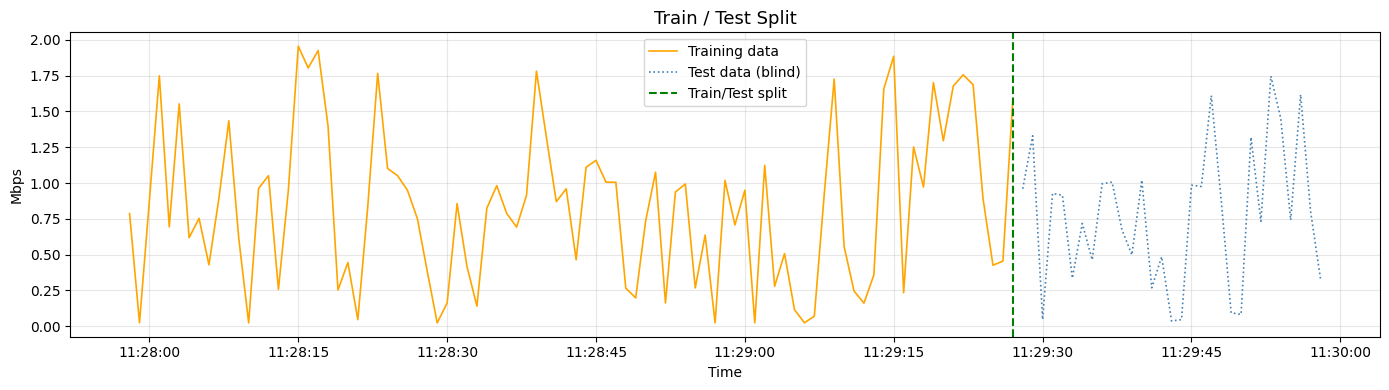

In [30]:
# Split into training and test sets
split_idx     = int(TRAINING_SPLIT * len(df))
training_data = df.iloc[:split_idx]
test_data     = df.iloc[split_idx:]

print(f'Total rows     : {len(df)}')
print(f'Training rows  : {len(training_data)}  '
      f'({TRAINING_SPLIT*100:.0f}%)  '
      f'{training_data.index.min().strftime("%H:%M:%S")} → '
      f'{training_data.index.max().strftime("%H:%M:%S")}')
print(f'Test rows      : {len(test_data)}  '
      f'({(1-TRAINING_SPLIT)*100:.0f}%)  '
      f'{test_data.index.min().strftime("%H:%M:%S")} → '
      f'{test_data.index.max().strftime("%H:%M:%S")}')

# Visualise the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(training_data['y'], color='orange',   linewidth=1.2, label='Training data')
ax.plot(test_data['y'],     color='steelblue',linewidth=1.2,
        linestyle='dotted', label='Test data (blind)')
ax.axvline(x=training_data.index.max(),
           color='green', linestyle='--', linewidth=1.5, label='Train/Test split')
ax.set_title('Train / Test Split', fontsize=13)
ax.set_xlabel('Time')
ax.set_ylabel('Mbps')
ax.legend()
plt.tight_layout()
plt.show()

---
## Stationarity Check (ADF Test)

ARIMA requires the time series to be **stationary**; meaning it oscillates
around a stable mean with no long-term trend.

We use the **Augmented Dickey-Fuller (ADF) test** to check this:

| p-value | Interpretation | ARIMA parameter |
|---------|---------------|----------------|
| < 0.05 | Stationary | d = 0 |
| ≥ 0.05 | Non-stationary | d = 1 (apply differencing) |

Our ON/OFF traffic cycles around a fixed mean — we expect it to be **stationary**,
meaning d = 0 is appropriate.

In [31]:
# Run ADF test on the TRAINING data only
# (never use test data to make modelling decisions)
series = training_data['y'].dropna()
result = adfuller(series, autolag='AIC')

print('Augmented Dickey-Fuller Test')
print('=' * 40)
print(f'Test Statistic   : {result[0]:.4f}')
print(f'p-value          : {result[1]:.4f}')
print(f'Lags used        : {result[2]}')
print(f'Observations     : {result[3]}')
print('\nCritical Values:')
for key, val in result[4].items():
    print(f'  {key}: {val:.4f}')
print('=' * 40)

if result[1] < 0.05:
    print(f'\nResult: p={result[1]:.4f} < 0.05  →  STATIONARY')
    print('Conclusion: d = 0 is appropriate for ARIMA')
else:
    print(f'\nResult: p={result[1]:.4f} ≥ 0.05  →  NON-STATIONARY')
    print('Conclusion: use d = 1 (differencing needed)')

Augmented Dickey-Fuller Test
Test Statistic   : -6.5585
p-value          : 0.0000
Lags used        : 0
Observations     : 89

Critical Values:
  1%: -3.5061
  5%: -2.8946
  10%: -2.5844

Result: p=0.0000 < 0.05  →  STATIONARY
Conclusion: d = 0 is appropriate for ARIMA


---
## ARIMA Model Training

We fit ARIMA **only on the training data** (75% of the series).
The model learns the autocorrelation structure of the ON/OFF traffic pattern
by estimating the AR weights using **Maximum Likelihood Estimation (MLE)**.

---

### The ARIMA Model Formula

ARIMA(p, d, q) is defined by the equation:

$$\phi(B)(1-B)^d \, y_t = \theta(B)\,\varepsilon_t$$

For our case ARIMA(**30, 0, 0**) — no differencing, no MA term — this expands to:

$$\hat{y}_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_{30} y_{t-30} + \varepsilon_t$$

| Symbol | Meaning |
|--------|---------|
| $\hat{y}_t$ | Predicted traffic at time $t$ (Mbps) |
| $\phi_1 \ldots \phi_{30}$ | AR weights — **learned from training data** |
| $y_{t-1} \ldots y_{t-30}$ | Last 30 observed values (look-back window) |
| $c$ | Constant intercept |
| $\varepsilon_t$ | White noise error term |

**Why p = 30?**  
Our ON/OFF cycle is 6 seconds (5s ON + 1s OFF).  
p = 30 = 5 × 6 covers **5 full cycles** of history — enough for ARIMA to learn the rhythm.

---

### How the Weights are Learned ( Maximum Likelihood Estimation)

ARIMA finds the values of $\phi_1 \ldots \phi_{30}$
that **maximise the probability** of observing our training data.

---

#### Step 1: Gaussian Error Assumption

The prediction error at each time step is:

$$\varepsilon_t = y_t - \hat{y}_t = y_t - (\phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_{30} y_{t-30})$$

ARIMA assumes these errors follow a **Gaussian (Normal) distribution** with zero mean:

$$\varepsilon_t \sim \mathcal{N}(0,\, \sigma^2)$$

The probability density of observing error $\varepsilon_t$ is:

$$f(\varepsilon_t) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{\varepsilon_t^2}{2\sigma^2}\right)$$

Substituting the full ARIMA prediction into the numerator gives the **probability of observing one traffic value** $y_t$:

$$\boxed{f(y_t \mid \phi_1,\ldots,\phi_{30},\sigma^2)
= \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{(y_t - \phi_1 y_{t-1} - \cdots - \phi_{30} y_{t-30})^2}
     {2\sigma^2}
\right)}$$

| Part | In our project |
|------|---------------|
| $y_t$ | Actual Mbps at second $t$ from the CSV |
| $\phi_1 y_{t-1} + \cdots + \phi_{30} y_{t-30}$ | ARIMA prediction using last 30 seconds |
| $(y_t - \hat{y}_t)^2$ | Squared error — penalises large mistakes |
| $\sigma^2$ | Error variance — estimated from 90 training rows |

> **Intuition:** Small errors give high probability. Large errors give very low probability.
> MLE finds the weights that keep all errors small — maximising the probability of what we actually observed.

---

#### Step 2: Joint Likelihood Over All Training Rows

Since each observation is independent, the probability of observing the **entire training set** is the product of all individual probabilities:

$$L(\phi_1,\ldots,\phi_{30},\sigma^2)
= \prod_{t=31}^{90}
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{(y_t - \phi_1 y_{t-1} - \cdots - \phi_{30} y_{t-30})^2}
     {2\sigma^2}
\right)$$

> **Note:** The product starts at $t=31$ because the AR(30) model needs the first 30 rows
> as initial conditions before it can make any predictions.
> So out of 90 training rows, **60 rows** contribute to the likelihood.

---

#### Step 3:  Log-Likelihood (easier to optimise)

Products are difficult to maximise directly. Taking the natural logarithm converts the product into a sum:

$$\ell(\phi, \sigma^2)
= -\frac{60}{2}\log(2\pi\sigma^2)
- \frac{1}{2\sigma^2}
\sum_{t=31}^{90}
\bigl(y_t - \phi_1 y_{t-1} - \cdots - \phi_{30} y_{t-30}\bigr)^2$$

---

#### Step 4: Maximise = Minimise Squared Errors

Maximising the log-likelihood with respect to $\phi_1,\ldots,\phi_{30}$ is mathematically equivalent to:

$$\min_{\phi_1,\ldots,\phi_{30}}
\sum_{t=31}^{90}
\bigl(y_t - \phi_1 y_{t-1} - \cdots - \phi_{30} y_{t-30}\bigr)^2$$

The **L-BFGS iterative optimiser** adjusts all 30 weights simultaneously until convergence:

```

In [32]:
print(f'Fitting ARIMA{ARIMA_ORDER} on {len(training_data)} training rows...')

# Fit on TRAINING data only
model        = ARIMA(training_data['y'], order=ARIMA_ORDER)
fitted_model = model.fit()

# In-sample fitted values training window only
in_sample_fit = fitted_model.fittedvalues.clip(lower=0)

# Out-of-sample forecast prediction of test window
n_test        = len(test_data)
raw_forecast  = fitted_model.forecast(steps=n_test)

# Re-assign timestamps so the forecast aligns with the test data on the plot
forecast_vals = pd.Series(
    raw_forecast.clip(0).values, # ensure no negative predictions 
    index=test_data.index
)

print(f'Training complete.')
print(f'In-sample fit  : {len(in_sample_fit)} values  '
      f'(mean: {in_sample_fit.mean():.4f} Mbps)')
print(f'Forecast       : {len(forecast_vals)} values  '
      f'(mean: {forecast_vals.mean():.4f} Mbps)')

Fitting ARIMA(30, 0, 0) on 90 training rows...
Training complete.
In-sample fit  : 90 values  (mean: 0.8260 Mbps)
Forecast       : 31 values  (mean: 0.7369 Mbps)


---

## Evaluation

We evaluate the forecast quality using two metrics, computed **only on the blind test window**:

| Metric | Formula | Meaning |
|--------|---------|---------|
| **MAE** | $\frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert$ | Average absolute error in Mbps |
| **RMSE** | $\sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$ | Penalises large errors more than MAE |


In [22]:
actual    = test_data['y'].values
predicted = forecast_vals.values

mae  = float(np.mean(np.abs(predicted - actual)))
rmse = float(np.sqrt(np.mean((predicted - actual) ** 2)))
mape = float(np.mean(np.abs((actual - predicted) /
             np.where(actual == 0, 1, actual))) * 100)

print('Evaluation on BLIND test window only')
print('=' * 40)
print(f'MAE   : {mae:.4f} Mbps')
print(f'RMSE  : {rmse:.4f} Mbps')
print(f'MAPE  : {mape:.2f}%  (ignoring zero bins)')
print('=' * 40)
print(f'\nContext: link capacity is 1–2 Mbps')
print(f'MAE of {mae:.4f} Mbps = {mae/1.5*100:.1f}% of average link capacity')

Evaluation on BLIND test window only
MAE   : 0.5001 Mbps
RMSE  : 0.6059 Mbps
MAPE  : 278.26%  (ignoring zero bins)

Context: link capacity is 1–2 Mbps
MAE of 0.5001 Mbps = 33.3% of average link capacity


---
## Summary

This cell prints a complete summary of the entire experiment.

In [24]:
print('=' * 50)
print('  SDN TRAFFIC PREDICTION — SUMMARY')
print('=' * 50)
print(f'\nData')
print(f'  CSV file        : {CSV_FILE}')
print(f'  Total samples   : {len(df)}')
print(f'  Sample period   : {SAMPLE_PERIOD}')
print(f'  Traffic range   : {df["y"].min():.4f} – {df["y"].max():.4f} Mbps')
print(f'  Mean traffic    : {df["y"].mean():.4f} Mbps')

print(f'\nModel')
print(f'  Algorithm       : ARIMA')
print(f'  Order (p, d, q) : {ARIMA_ORDER}')
print(f'  p = {ARIMA_ORDER[0]} : uses last {ARIMA_ORDER[0]} seconds of history')
print(f'  d = {ARIMA_ORDER[1]} : {"no differencing (stationary)" if ARIMA_ORDER[1]==0 else "one differencing step"}')
print(f'  q = {ARIMA_ORDER[2]} : {"no MA term" if ARIMA_ORDER[2]==0 else f"{ARIMA_ORDER[2]} past errors used"}')

print(f'\nSplit')
print(f'  Training        : {len(training_data)} rows ({TRAINING_SPLIT*100:.0f}%)')
print(f'  Test (blind)    : {len(test_data)} rows ({(1-TRAINING_SPLIT)*100:.0f}%)')

print(f'\nResults (blind test window only)')
print(f'  MAE             : {mae:.4f} Mbps')
print(f'  RMSE            : {rmse:.4f} Mbps')
print('=' * 50)

  SDN TRAFFIC PREDICTION — SUMMARY

Data
  CSV file        : captures2/s2/eth2.csv
  Total samples   : 121
  Sample period   : 1s
  Traffic range   : 0.0231 – 1.9563 Mbps
  Mean traffic    : 0.8222 Mbps

Model
  Algorithm       : ARIMA
  Order (p, d, q) : (30, 0, 0)
  p = 30 : uses last 30 seconds of history
  d = 0 : no differencing (stationary)
  q = 0 : no MA term

Split
  Training        : 90 rows (75%)
  Test (blind)    : 31 rows (25%)

Results (blind test window only)
  MAE             : 0.5001 Mbps
  RMSE            : 0.6059 Mbps


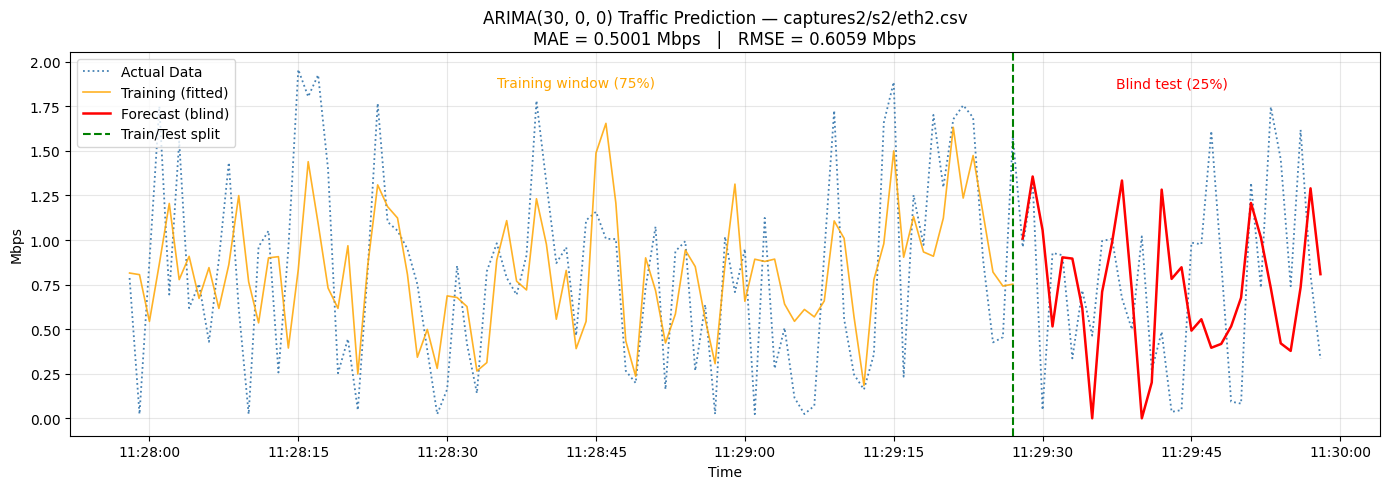

Plot saved as prediction_result.png


In [25]:
fig, ax = plt.subplots(figsize=(14, 5))

# Actual data — full window
ax.plot(df['y'],
        label='Actual Data',
        linestyle='dotted',
        color='steelblue',
        linewidth=1.3)

# In-sample fit — training window only
ax.plot(in_sample_fit,
        label='Training (fitted)',
        color='orange',
        linewidth=1.2,
        alpha=0.85)

# Blind forecast — test window only
ax.plot(forecast_vals,
        label='Forecast (blind)',
        color='red',
        linewidth=1.8)

# Train/test split line
ax.axvline(
    x=training_data.index.max(),
    color='green',
    linestyle='--',
    linewidth=1.5,
    label='Train/Test split'
)

# Annotations
ax.text(training_data.index[len(training_data)//2],
        df['y'].max() * 0.95,
        'Training window (75%)',
        ha='center', color='orange', fontsize=10)

ax.text(test_data.index[len(test_data)//2],
        df['y'].max() * 0.95,
        'Blind test (25%)',
        ha='center', color='red', fontsize=10)

ax.set_title(
    f'ARIMA{ARIMA_ORDER} Traffic Prediction — {CSV_FILE}\n'
    f'MAE = {mae:.4f} Mbps   |   RMSE = {rmse:.4f} Mbps',
    fontsize=12
)
ax.set_xlabel('Time')
ax.set_ylabel('Mbps')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as prediction_result.png')


  Switch: s1

  Interface: eth1
    Loaded 121 rows  | mean=0.9542 Mbps  | max=2.5312 Mbps
    MAE=0.5731 Mbps   RMSE=0.6794 Mbps

  Interface: eth2
    Loaded 121 rows  | mean=1.0079 Mbps  | max=2.4286 Mbps
    MAE=0.6439 Mbps   RMSE=0.7639 Mbps

  Interface: eth3
    Loaded 121 rows  | mean=1.1249 Mbps  | max=2.5618 Mbps
    MAE=0.6389 Mbps   RMSE=0.7239 Mbps


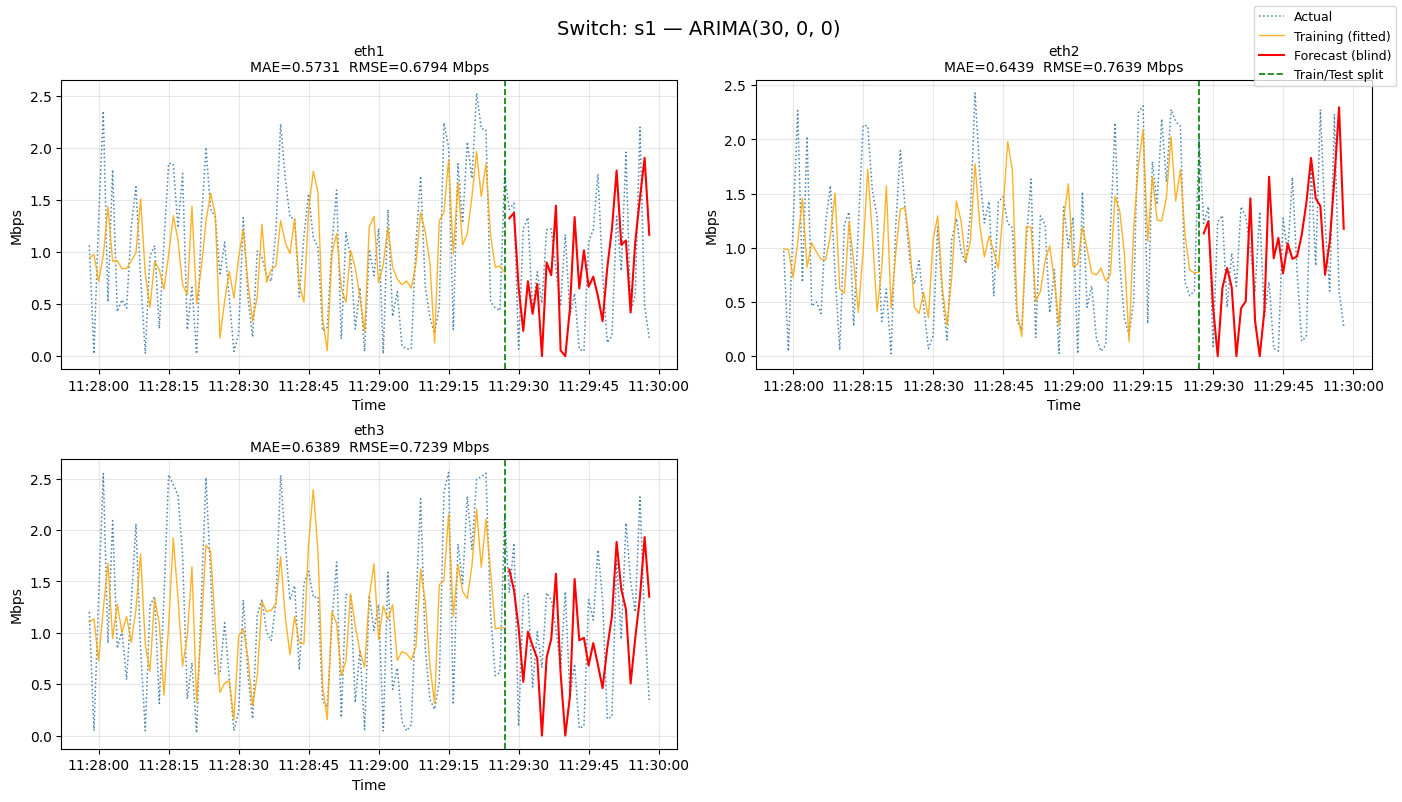


  Saved → plots_all\s1.png

  Switch: s2

  Interface: eth1
    Loaded 121 rows  | mean=1.1319 Mbps  | max=2.5618 Mbps
    MAE=0.6447 Mbps   RMSE=0.7578 Mbps

  Interface: eth2
    Loaded 121 rows  | mean=0.8222 Mbps  | max=1.9563 Mbps
    MAE=0.5001 Mbps   RMSE=0.6059 Mbps

  Interface: eth3
    Loaded 121 rows  | mean=0.3286 Mbps  | max=0.8205 Mbps


C:\Users\yohan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    MAE=0.2046 Mbps   RMSE=0.2490 Mbps


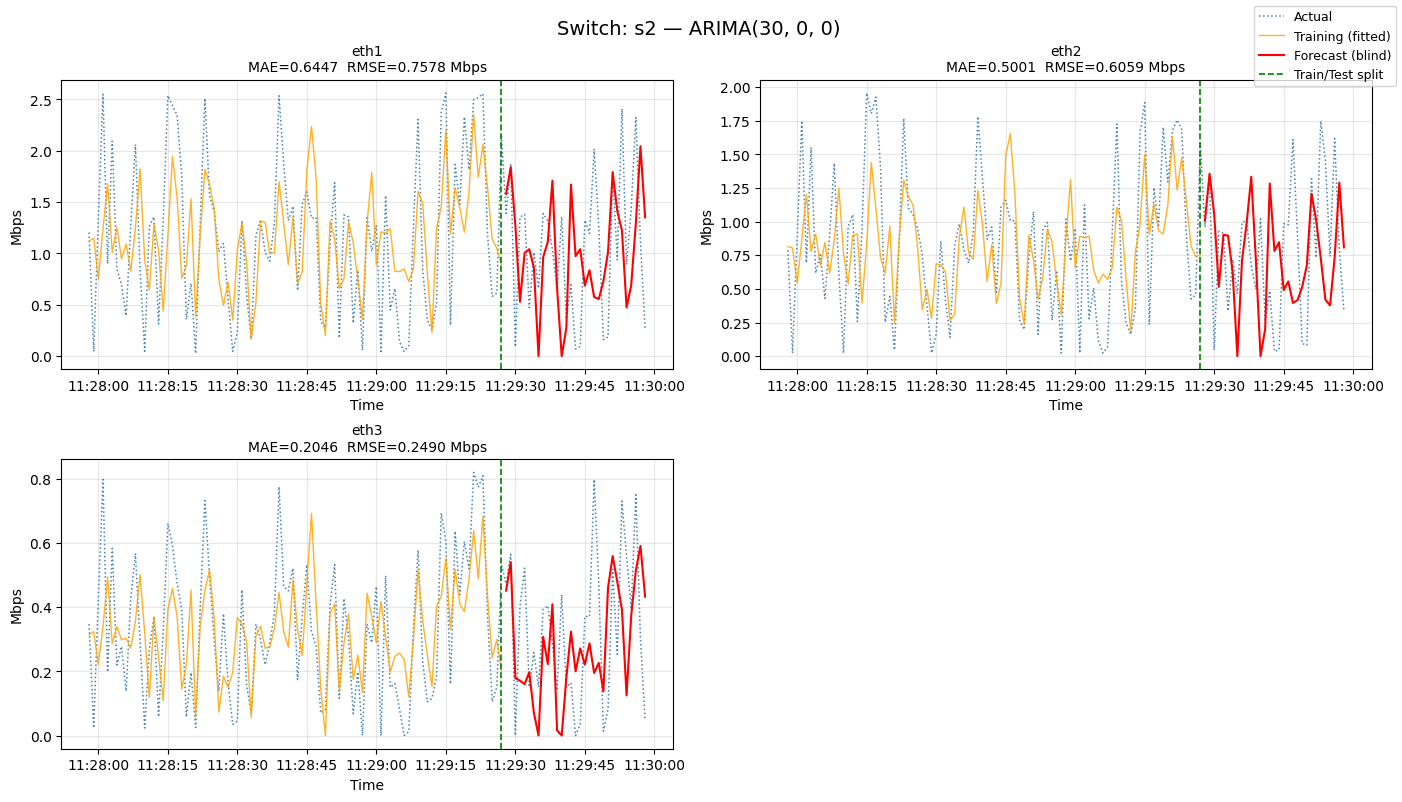


  Saved → plots_all\s2.png

  SUMMARY — All interfaces
Switch Interface    MAE   RMSE
    s1      eth1 0.5731 0.6794
    s1      eth2 0.6439 0.7639
    s1      eth3 0.6389 0.7239
    s2      eth1 0.6447 0.7578
    s2      eth2 0.5001 0.6059
    s2      eth3 0.2046 0.2490

Overall average MAE  : 0.5342 Mbps
Overall average RMSE : 0.6300 Mbps

Best interface  : s2/eth3  MAE=0.2046 Mbps
Worst interface : s2/eth1  MAE=0.6447 Mbps
Styler unavailable (jinja2 likely missing): The '.style' accessor requires jinja2
Attempting to install jinja2...
Auto-install failed or still unavailable: The '.style' accessor requires jinja2


,Switch,Interface,MAE,RMSE
0,s1,eth1,0.5731,0.6794
1,s1,eth2,0.6439,0.7639
2,s1,eth3,0.6389,0.7239
3,s2,eth1,0.6447,0.7578
4,s2,eth2,0.5001,0.6059
5,s2,eth3,0.2046,0.2490


In [26]:
# ── Predict all interfaces across all switches ────────────────────────────

import math
import os

# Root captures folder
CAPTURES_ROOT = 'captures2'
SAVE_FOLDER   = 'plots_all'
os.makedirs(SAVE_FOLDER, exist_ok=True)

# Summary table to collect all results
summary = []

for switch in sorted(os.listdir(CAPTURES_ROOT)):
    switch_path = os.path.join(CAPTURES_ROOT, switch)
    if not os.path.isdir(switch_path):
        continue

    csv_files = sorted(f for f in os.listdir(switch_path) if f.endswith('.csv'))

    if len(csv_files) <= 1:
        print(f'Skipping {switch} — only {len(csv_files)} interface(s)')
        continue

    print(f'\n{"="*50}')
    print(f'  Switch: {switch}')
    print(f'{"="*50}')

    # Create subplot grid — one subplot per interface
    n_plots = len(csv_files)
    n_cols  = math.ceil(math.sqrt(n_plots))
    n_rows  = math.ceil(n_plots / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols,
                            figsize=(7 * n_cols, 4 * n_rows),
                            sharey=False, sharex=False)
    axs = np.array(axs).flatten()

    for ax, csv_file in zip(axs, csv_files):
        iface     = csv_file[:-4]   # remove .csv
        full_path = os.path.join(switch_path, csv_file)
        print(f'\n  Interface: {iface}')

        # ── Load and process ─────────────────────────────────────────────
        try:
            df_iface = pd.read_csv(full_path)
            df_iface['ds'] = pd.to_datetime(df_iface['ds'], unit='s')
            df_iface.set_index('ds', inplace=True)
            df_iface = (df_iface
                        .resample(SAMPLE_PERIOD)
                        .sum(numeric_only=True)
                        .fillna(0))
            bin_s = pd.Timedelta(SAMPLE_PERIOD).total_seconds()
            df_iface['y'] = (df_iface['y'] * 8) / (bin_s * 2**20)
            print(f'    Loaded {len(df_iface)} rows  '
                  f'| mean={df_iface["y"].mean():.4f} Mbps  '
                  f'| max={df_iface["y"].max():.4f} Mbps')
        except Exception as e:
            print(f'    ERROR loading: {e}')
            ax.axis('off')
            continue

        # ── Split ────────────────────────────────────────────────────────
        split_idx  = int(TRAINING_SPLIT * len(df_iface))
        train_i    = df_iface.iloc[:split_idx]
        test_i     = df_iface.iloc[split_idx:]

        if len(test_i) == 0:
            print(f'    SKIP — no test rows')
            ax.axis('off')
            continue

        # ── Fit ARIMA ────────────────────────────────────────────────────
        try:
            model_i  = ARIMA(train_i['y'], order=ARIMA_ORDER)
            fitted_i = model_i.fit()
        except Exception as e:
            print(f'    ERROR fitting ARIMA: {e}')
            ax.set_title(f'{iface}\n(fit failed)')
            ax.axis('off')
            continue

        # In-sample fit (training window)
        insample_i = fitted_i.fittedvalues.clip(lower=0)

        # Blind forecast (test window)
        forecast_i = pd.Series(
            fitted_i.forecast(steps=len(test_i)).clip(0).values,
            index=test_i.index
        )

        # ── Metrics ──────────────────────────────────────────────────────
        mae_i  = float(np.mean(np.abs(forecast_i.values - test_i['y'].values)))
        rmse_i = float(np.sqrt(np.mean((forecast_i.values - test_i['y'].values)**2)))
        print(f'    MAE={mae_i:.4f} Mbps   RMSE={rmse_i:.4f} Mbps')

        summary.append({
            'Switch':    switch,
            'Interface': iface,
            'MAE':       round(mae_i,  4),
            'RMSE':      round(rmse_i, 4)
        })

        # ── Plot ─────────────────────────────────────────────────────────
        ax.plot(df_iface['y'],
                label='Actual', linestyle='dotted',
                color='steelblue', linewidth=1.1)
        ax.plot(insample_i,
                label='Training (fitted)',
                color='orange', linewidth=1.0, alpha=0.85)
        ax.plot(forecast_i,
                label='Forecast (blind)',
                color='red', linewidth=1.5)
        ax.axvline(x=train_i.index.max(),
                   color='green', linestyle='--',
                   linewidth=1.2, label='Train/Test split')
        ax.set_title(f'{iface}\nMAE={mae_i:.4f}  RMSE={rmse_i:.4f} Mbps',
                     fontsize=10)
        ax.set_xlabel('Time')
        ax.set_ylabel('Mbps')

    # Hide unused subplots
    for ax in axs[n_plots:]:
        ax.axis('off')

    # Shared legend from first subplot
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fancybox=True, fontsize=9)
    fig.suptitle(f'Switch: {switch} — ARIMA{ARIMA_ORDER}', fontsize=14)

    plt.tight_layout(pad=0.8)
    out_path = os.path.join(SAVE_FOLDER, f'{switch}.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n  Saved → {out_path}')

# ── Summary table ─────────────────────────────────────────────────────────
print(f'\n{"="*50}')
print('  SUMMARY — All interfaces')
print(f'{"="*50}')
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print(f'\nOverall average MAE  : {summary_df["MAE"].mean():.4f} Mbps')
print(f'Overall average RMSE : {summary_df["RMSE"].mean():.4f} Mbps')
print(f'\nBest interface  : {summary_df.loc[summary_df["MAE"].idxmin(), "Switch"]}/'
      f'{summary_df.loc[summary_df["MAE"].idxmin(), "Interface"]}  '
      f'MAE={summary_df["MAE"].min():.4f} Mbps')
print(f'Worst interface : {summary_df.loc[summary_df["MAE"].idxmax(), "Switch"]}/'
      f'{summary_df.loc[summary_df["MAE"].idxmax(), "Interface"]}  '
      f'MAE={summary_df["MAE"].max():.4f} Mbps')
try:
    from jinja2 import Template  # check if jinja2 is available
    display(summary_df.style
            .highlight_min(subset='MAE', color='lightgreen')
            .highlight_max(subset='MAE', color='lightsalmon')
            .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}'}))
except Exception as e:
    print('Styler unavailable (jinja2 likely missing):', e)
    # Try to install jinja2 automatically and re-try displaying styled table
    try:
        import sys, subprocess
        print('Attempting to install jinja2...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'jinja2'])
        # re-import and display styled DataFrame
        from jinja2 import Template
        display(summary_df.style
                .highlight_min(subset='MAE', color='lightgreen')
                .highlight_max(subset='MAE', color='lightsalmon')
                .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}'}))
    except Exception as e2:
        print('Auto-install failed or still unavailable:', e2)
        display(summary_df)